# **Data importing and data standardization and correlation heat map**

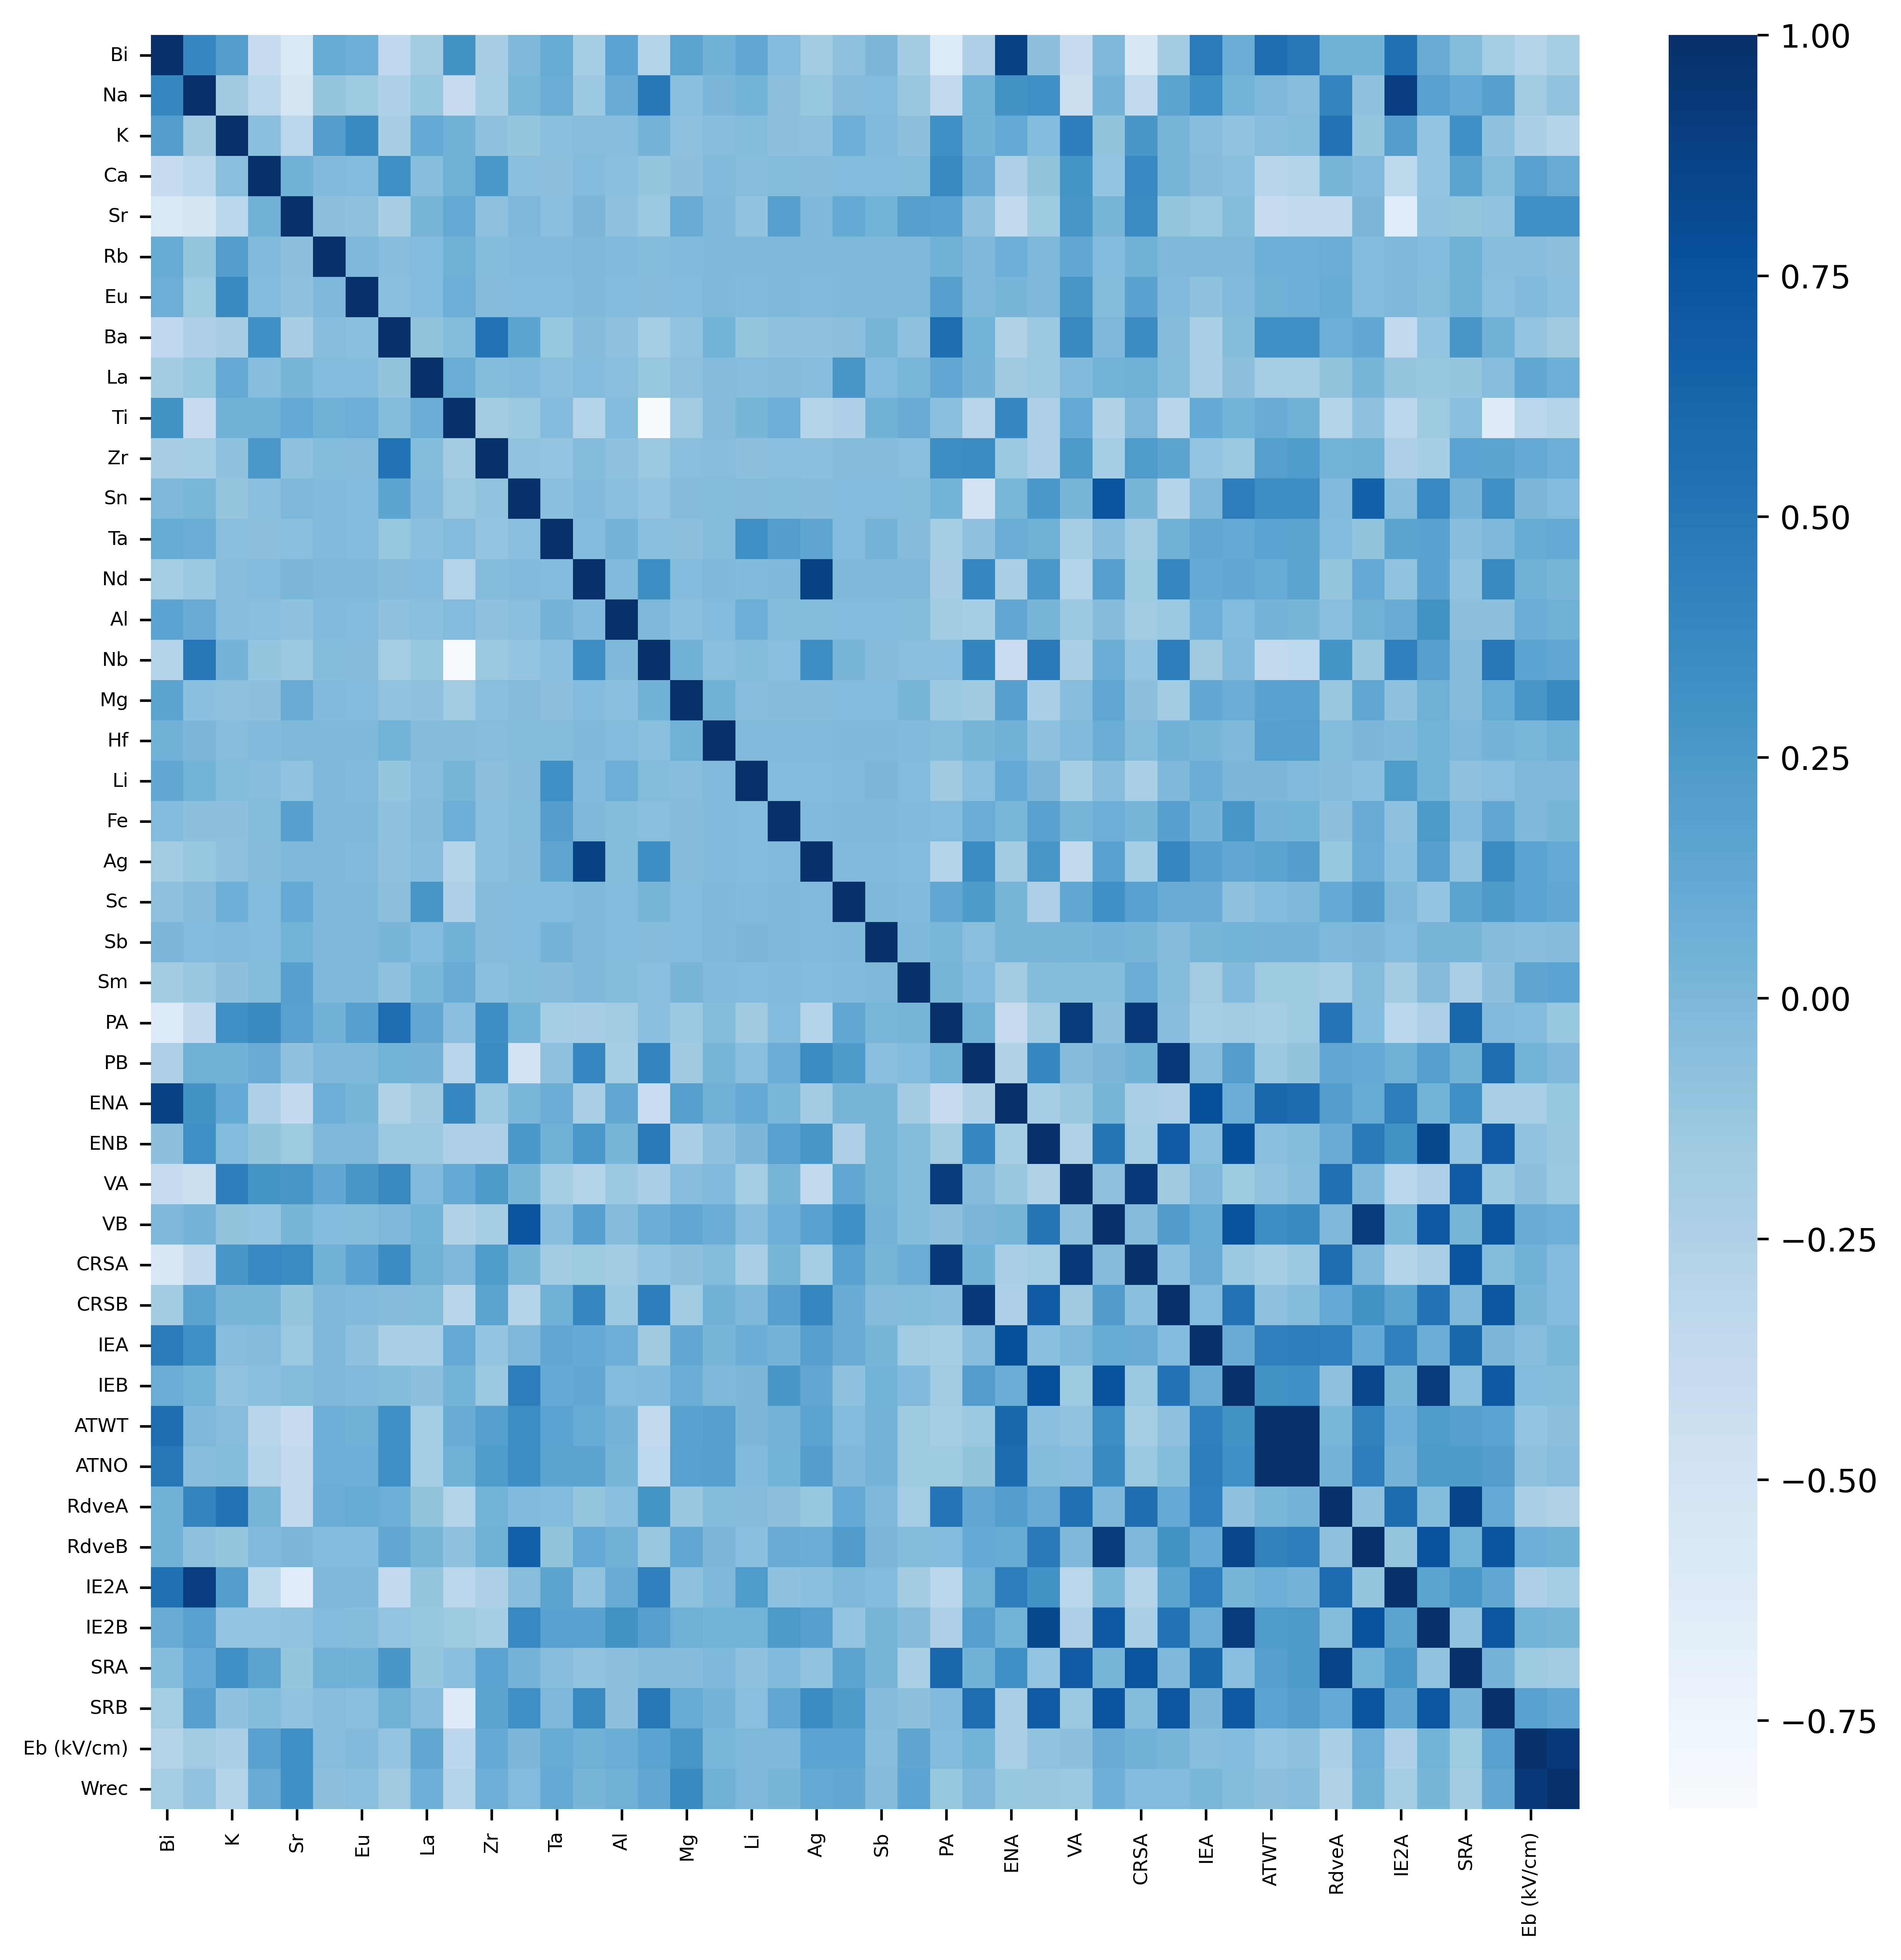

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import copy


train = pd.read_excel("BNT-Energy2f.xlsx")
X=train.iloc[:,:-1]
Y=train.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


scalerX = StandardScaler().fit(X_train)
scalery = StandardScaler().fit(y_train.values.reshape(-1,1))
X_train1 = scalerX.transform(X_train)
y_train1 = scalery.transform(y_train.values.reshape(-1,1))
X_test1 = scalerX.transform(X_test)
y_test1 = scalery.transform(y_test.values.reshape(-1,1))
y_new_inverse = scalery.inverse_transform(y_test1.reshape(-1,1))
X_train2=copy.deepcopy(X_train1)
y_train2=copy.deepcopy(y_train1)
#print(y_new_inverse)
#train.corr()
#sns.heatmap(train.corr(), cmap="YlGnBu", annot=False)

import matplotlib.pyplot as plt
import seaborn as sns

corr = train.corr() #your dataframe

# figsize=(6, 6) control width and height
# dpi = 600, I
plt.figure(figsize=(10, 10),
           dpi = 600)

# parameter annot_kws={"size": 8} control corr values font size
sns.heatmap(corr, cmap="Blues", annot=False, annot_kws={"size": 2})

plt.tick_params(axis = 'x', labelsize = 6) # x font label size
plt.tick_params(axis = 'y', labelsize = 6) # y font label size

# **Model defining and training and best parameters with performance metric**

In [25]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression
from xgboost import XGBRegressor
# from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

xgb_model=XGBRegressor()

search_space={'n_estimators':[100,200,300,400,500,600,800],'max_depth':[3,4,6,7,9],'gamma0':[0.01],'learning_rate':[0.001,0.01,0.05,0.1,0.5,1]}


In [10]:
from sklearn.model_selection import GridSearchCV

GS=GridSearchCV(estimator=xgb_model,param_grid=search_space,scoring=["r2","neg_root_mean_squared_error"],refit="neg_root_mean_squared_error",cv=5,verbose=4)
GS.fit(X_train1,y_train1)

Fitting 5 folds for each of 210 candidates, totalling 1050 fits
[CV 1/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.792) r2: (test=0.143) total time=   0.1s
[CV 2/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-1.019) r2: (test=0.139) total time=   0.1s
[CV 3/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.978) r2: (test=0.144) total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 4/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-0.763) r2: (test=0.147) total time=   0.1s
[CV 5/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=100; neg_root_mean_squared_error: (test=-1.042) r2: (test=0.126) total time=   0.1s
[CV 1/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.726) r2: (test=0.279) total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:05:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 2/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.938) r2: (test=0.271) total time=   0.1s
[CV 3/5] END gamma0=0.01, learning_rate=0.001, max_depth=3, n_estimators=200; neg_root_mean_squared_error: (test=-0.905) r2: (test=0.267) total time=   0.1s


...

[CV 2/5] END gamma0=0.01, learning_rate=1, max_depth=9, n_estimators=800; neg_root_mean_squared_error: (test=-0.453) r2: (test=0.830) total time=   0.2s
[CV 3/5] END gamma0=0.01, learning_rate=1, max_depth=9, n_estimators=800; neg_root_mean_squared_error: (test=-0.462) r2: (test=0.809) total time=   0.2s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:11:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:11:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV 4/5] END gamma0=0.01, learning_rate=1, max_depth=9, n_estimators=800; neg_root_mean_squared_error: (test=-0.384) r2: (test=0.783) total time=   0.2s
[CV 5/5] END gamma0=0.01, learning_rate=1, max_depth=9, n_estimators=800; neg_root_mean_squared_error: (test=-0.618) r2: (test=0.692) total time=   0.2s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:11:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:11:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma0" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma0': [0.01],
                         'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
                         'max_depth': [3, 4, 6, 7, 9],
                         'n_estimators': [100, 200, 300, 400, 500, 600, 800]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_root_mean_squared_error'], verbose=4)

In [12]:
print(GS.best_params_) # ND gamma0=0.01, learning_rate=0.01, max_depth=9, n_estimators=800;
print(GS.best_score_)
from sklearn.metrics import r2_score
model_xgb=XGBRegressor(n_estimators=800,max_depth=3,eta=0.01)
model_xgb.fit(X_train1,y_train1)
#y_pred=model_xgb.predict(X_test1)

#y_new_inverse = scalery.inverse_transform(y_pred.reshape(-1,1))
#Y_true=scalery.inverse_transform(y_test1)
#r2_score(Y_true,y_new_inverse)

{'gamma0': 0.01, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 800}
-0.35812038335964436


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.01, eval_metric=None,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=None, ...)


# **Model Prediction and plot with error bars using bootstrapping**

In [13]:
from sklearn.metrics import mean_squared_error
bootstrap_means=[]
bootstrap_means2=[]

N=500
for i in range(0,N):
  sample_index=np.random.choice(range(0,len(y_train1)),len(y_train1))

  X_samples=X_train1[sample_index]
  y_samples=y_train1[sample_index]
  print(i)

  model_xgb=XGBRegressor(n_estimators=800,max_depth=3,eta=0.01)

  model_xgb.fit(X_samples, y_samples)
  y_prediction=model_xgb.predict(X_test1)
  y_train2_prediction=model_xgb.predict(X_train2)
  bootstrap_means.append(scalery.inverse_transform(y_prediction.reshape(-1,1)))
  bootstrap_means2.append(scalery.inverse_transform(y_train2_prediction.reshape(-1,1)))

bootstrap_means_array=np.array(bootstrap_means)
bootstrap_means2_array=np.array(bootstrap_means2)

print(r2_score(scalery.inverse_transform(y_test1),bootstrap_means_array.mean(0)))
#print(mean_squared_error(scalery.inverse_transform(y_test1),bootstrap_means_array.mean(0)))
print(np.sqrt(mean_squared_error(scalery.inverse_transform(y_test1),bootstrap_means_array.mean(0))))
print(np.mean(np.abs(y_test1-bootstrap_means_array.mean(0))))

print(r2_score(scalery.inverse_transform(y_train2),bootstrap_means2_array.mean(0)))
#print(mean_squared_error(scalery.inverse_transform(y_train2),bootstrap_means2_array.mean(0)))
print(np.sqrt(mean_squared_error(scalery.inverse_transform(y_train2),bootstrap_means2_array.mean(0))))

# Define file names for training and testing data
train_file = 'train_data_output_final.xlsx'
test_file = 'test_data_output_final.xlsx'

# Save the training data to an Excel file
train_data_output_final = pd.concat([X_train, y_train], axis=1)
train_data_output_final.to_excel(train_file, index=False)

# Save the testing data to an Excel file
test_data_output_final = pd.concat([X_test, y_test], axis=1)
test_data_output_final.to_excel(test_file, index=False)

# Add predictions to the 'test' DataFrame
test_data_output_final['Predicted_Wrec'] = bootstrap_means_array.mean(0)
test_data_output_final['Error'] = bootstrap_means_array.std(0)

# Add predictions to the 'train' DataFrame
train_data_output_final['Predicted_Wrec'] = bootstrap_means2_array.mean(0)
train_data_output_final['Error'] = bootstrap_means2_array.std(0)

# Save the updated DataFrame with predictions to a new file
output_file = 'test_predicted_Wrec-new-feature.xlsx.'  # Update with the desired output file path
test_data_output_final.to_excel('test_predicted_Wrec-new-feature.xlsx', index=False)

# Save the updated DataFrame with predictions to a new file
output_file = 'train_predicted_Wrec-new-feature.xlsx.'  # Update with the desired output file path
train_data_output_final.to_excel('train_predicted_Wrec-new-feature.xlsx', index=False)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [26]:
GS11=XGBRegressor(n_estimators=800,max_depth=3,eta=0.01)
GS11.fit(X_train1,y_train1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.01, eval_metric=None,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=None, ...)

# **Features Importance**

In [28]:
from matplotlib import pyplot
from xgboost import XGBClassifier
from xgboost import plot_importance
import pandas as pd
dictionary={}
for col,score in zip(train.columns,GS11.feature_importances_):
    print(col,score)
    dictionary[col]=score


print(GS11.feature_importances_)
feature_important = model_xgb.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=True)

Bi 0.009708201
Na 0.0056240736
K 0.009717204
Ca 0.012810352
Sr 0.019699773
Rb 0.0
Eu 0.0046884655
Ba 0.0034646858
La 0.014815545
Ti 0.003985144
Zr 0.008508751
Sn 0.0023378453
Ta 0.013427607
Nd 0.0
Al 0.0012681646
Nb 0.012013792
Mg 0.035458382
Hf 0.03368758
Li 0.0
Fe 0.0033751896
Ag 0.0
Sc 0.0
Sb 0.0
Sm 0.0
PA 0.029489104
PB 0.011527687
ENA 0.011831616
ENB 0.006720887
VA 0.019776622
VB 0.0023528088
CRSA 0.03374949
CRSB 0.011853614
IEA 0.026144724
IEB 0.009387128
ATWT 0.004098867
ATNO 0.0022248381
RdveA 0.009557229
RdveB 0.014861569
IE2A 0.029963193
IE2B 0.0028583887
SRA 0.028575417
SRB 0.024545487
Eb (kV/cm) 0.5258906
[0.0097082  0.00562407 0.0097172  0.01281035 0.01969977 0.
 0.00468847 0.00346469 0.01481554 0.00398514 0.00850875 0.00233785
 0.01342761 0.         0.00126816 0.01201379 0.03545838 0.03368758
 0.         0.00337519 0.         0.         0.         0.
 0.0294891  0.01152769 0.01183162 0.00672089 0.01977662 0.00235281
 0.03374949 0.01185361 0.02614472 0.00938713 0.00409887 

In [7]:
from collections import OrderedDict
import numpy as np

keys = list(dictionary.keys())
values = list(dictionary.values())
sorted_value_index = np.argsort(values)
sorted_dict = {keys[i]: values[i] for i in sorted_value_index}

print(sorted_dict)

{'Eu': np.float32(0.0), 'Rb': np.float32(0.0), 'Sm': np.float32(0.0), 'Li': np.float32(0.0), 'Ag': np.float32(0.0), 'Sb': np.float32(0.0), 'Sn': np.float32(9.002112e-05), 'Al': np.float32(0.0007682951), 'Fe': np.float32(0.00086431945), 'CRSB': np.float32(0.0011531439), 'IEB': np.float32(0.0012977843), 'ATNO': np.float32(0.0015466061), 'Nb': np.float32(0.0024236063), 'Ti': np.float32(0.002508905), 'Nd': np.float32(0.0025427965), 'Sc': np.float32(0.0026178441), 'IE2B': np.float32(0.002938907), 'Ba': np.float32(0.0029475074), 'VB': np.float32(0.0036541263), 'Na': np.float32(0.0040762583), 'K': np.float32(0.004612438), 'RdveA': np.float32(0.004686194), 'Ca': np.float32(0.0047625788), 'La': np.float32(0.005391778), 'Bi': np.float32(0.007225037), 'PA': np.float32(0.0076509304), 'VA': np.float32(0.00791502), 'SRA': np.float32(0.009036259), 'ENA': np.float32(0.009608494), 'IE2A': np.float32(0.009613343), 'ATWT': np.float32(0.011604668), 'Ta': np.float32(0.01280841), 'CRSA': np.float32(0.014190